In [20]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)




*File load (dataset loading)*

In [21]:
df=pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [22]:
df.shape

(154621, 31)

In [23]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

**Fraud count check**

In [24]:
df['Class'].value_counts()

,count
Class,
0.0,154282
1.0,338


In [25]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0.0,0.997814
1.0,0.002186


Simple visulaization Fraud vs geninune

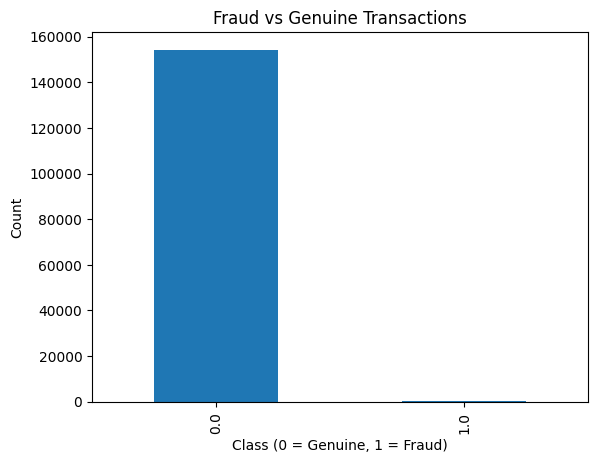

In [26]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

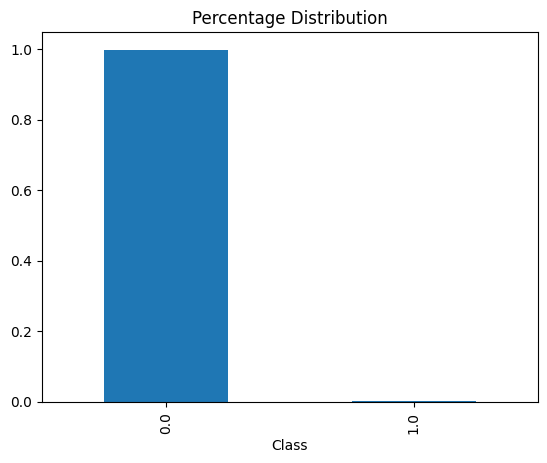

In [27]:
df['Class'].value_counts(normalize=True).plot(kind='bar')
plt.title("Percentage Distribution")
plt.show()

Amount Distribution

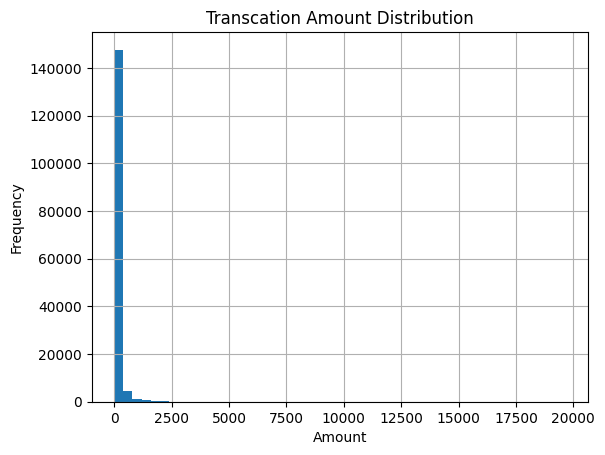

In [28]:
df['Amount'].hist(bins=50)
plt.title("Transcation Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

Fraud vs Amount

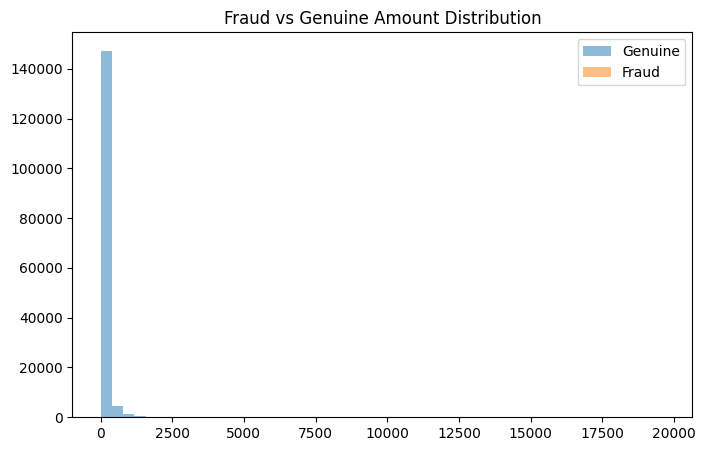

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.5, label='Genuine')
plt.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.5, label='Fraud')
plt.legend()
plt.title("Fraud vs Genuine Amount Distribution")
plt.show()

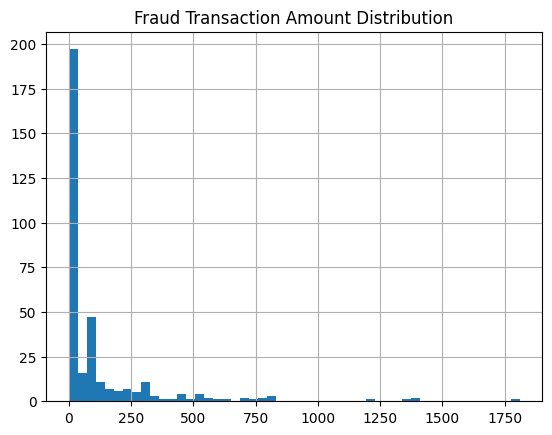

In [30]:
df[df['Class']==1]['Amount'].hist(bins=50)
plt.title("Fraud Transaction Amount Distribution")
plt.show()

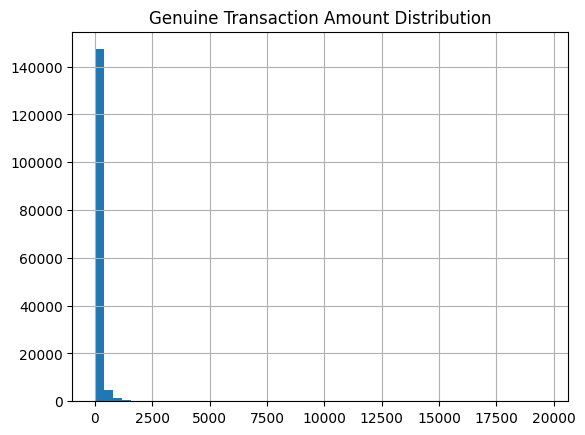

In [31]:
df[df['Class']==0]['Amount'].hist(bins=50)
plt.title("Genuine Transaction Amount Distribution")
plt.show()

Correlation

Text(0.5, 1.0, 'Correlation Matrix')

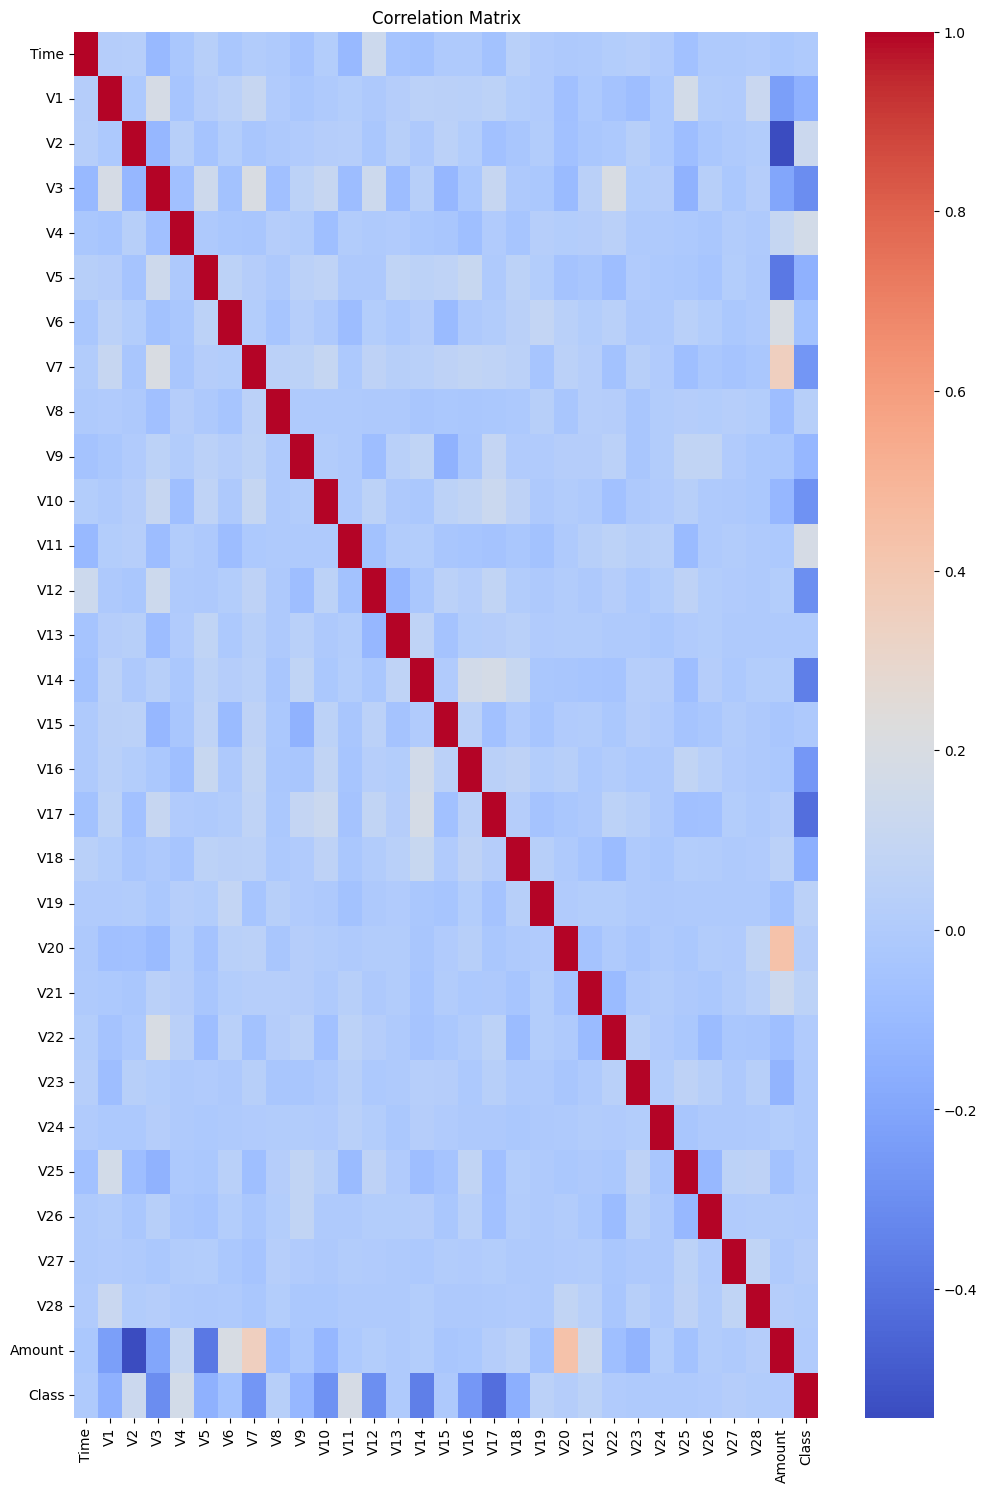

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix=df.corr()
plt.figure(figsize=(12,18))
sns.heatmap(corr_matrix,cmap='coolwarm')
plt.title("Correlation Matrix")



In [33]:
corr_with_class = df.corr()['Class'].sort_values(ascending=False)
print(corr_with_class)


Class     1.000000
V11       0.182321
V4        0.163265
V2        0.126428
V21       0.054524
V19       0.048880
V8        0.030658
V27       0.023151
V20       0.022677
V28       0.008152
Amount    0.004760
V22       0.003437
V26       0.000628
V25      -0.001637
V23      -0.002679
Time     -0.004351
V13      -0.005584
V24      -0.005715
V15      -0.009664
V6       -0.056163
V9       -0.118225
V5       -0.150193
V1       -0.150932
V18      -0.162574
V16      -0.261851
V7       -0.270665
V10      -0.284376
V12      -0.299181
V3       -0.303436
V14      -0.359269
V17      -0.420117
Name: Class, dtype: float64


# Top features:Strong Postive
* V11 : 0.15
* V4 : 0.13
* V2 : 0.09
# Strong **Negative** Correlation:
Top features:
* V17 : -0.32
* V14 : -0.30
* V12 : -0.26
* V10 : -0.21

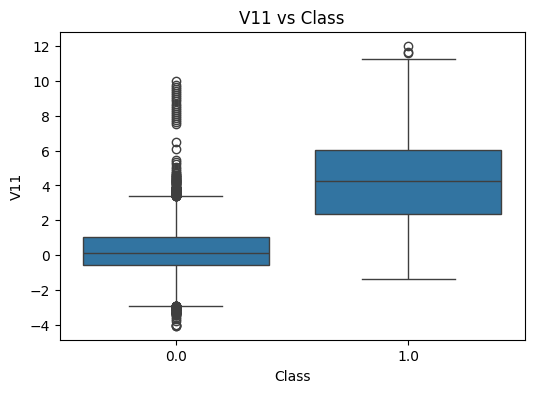

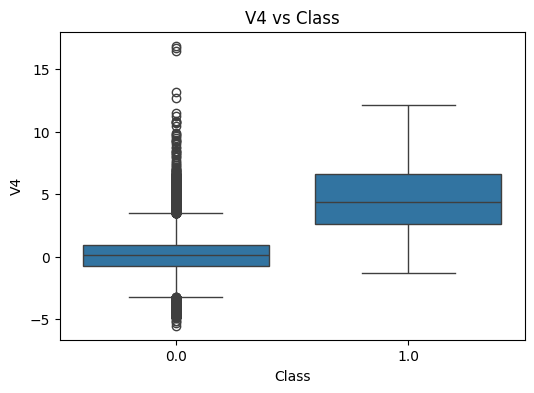

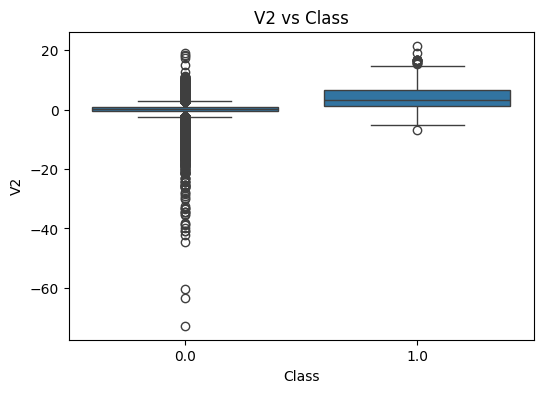

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

positive_features = ['V11', 'V4', 'V2']

for feature in positive_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Class', y=feature, data=df)
    plt.title(f"{feature} vs Class")
    plt.show()

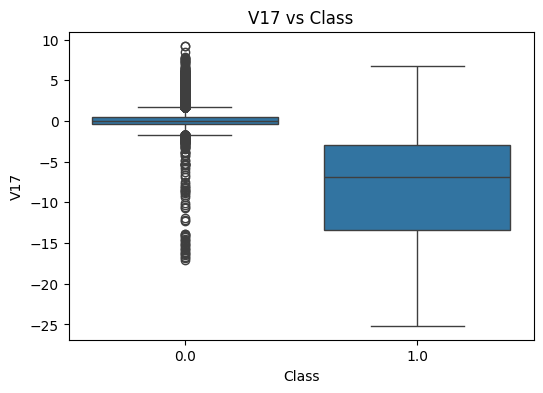

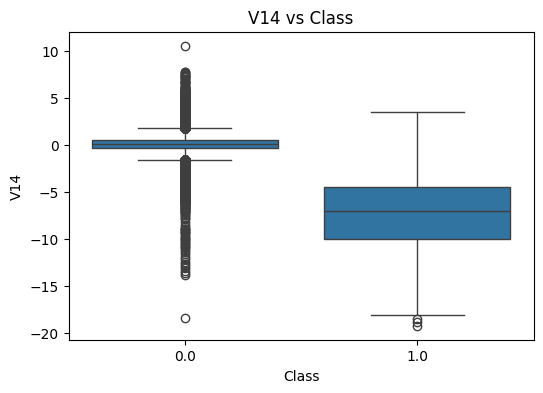

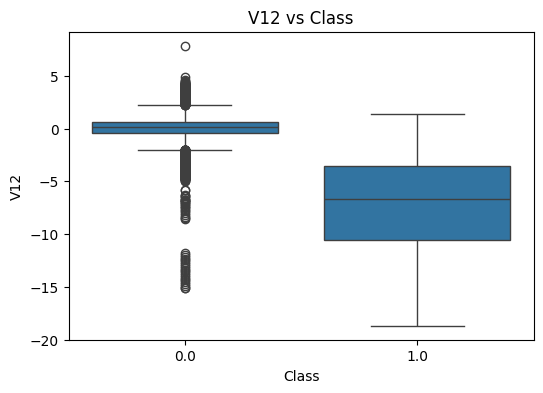

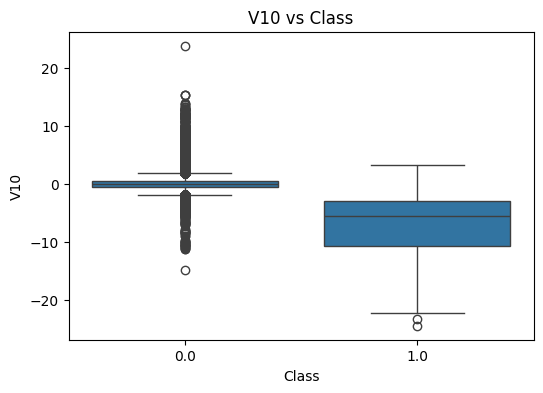

In [35]:
negative_features = ['V17', 'V14', 'V12', 'V10']

for feature in negative_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Class', y=feature, data=df)
    plt.title(f"{feature} vs Class")
    plt.show()

# **Data Preprocessing**

**Feature & Target Define**

In [36]:
X = df.drop('Class', axis=1)
y = df['Class']

**Train-Test with Stratified used**

In [37]:
from sklearn.model_selection import train_test_split

# Remove rows where 'y' contains NaN values, and remove corresponding rows from X
nan_mask = y.isna()
X_cleaned = X[~nan_mask]
y_cleaned = y[~nan_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, test_size=0.2, random_state=42, stratify=y_cleaned
)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

**Scaling**

In [39]:
from sklearn.preprocessing import StandardScaler

X_train[['Time','Amount']] = scaler.fit_transform(X_train[['Time','Amount']])
X_test[['Time','Amount']] = scaler.transform(X_test[['Time','Amount']])

# Imbalance Dataset

Here we use all three imbalance techniques to handle the imbalance data. We use here:
* Undersampling
* Oversampling
* Smote

# Undersampling

In [40]:
# Combine train data
#undersampling on train data only
train_data = X_train.copy()
train_data['Class'] = y_train

fraud = train_data[train_data['Class'] == 1]
genuine = train_data[train_data['Class'] == 0]

genuine_sample = genuine.sample(n=len(fraud), random_state=42)

train_balanced = pd.concat([fraud, genuine_sample])

# Shuffle
train_balanced = train_balanced.sample(frac=1, random_state=42)

# Split again
X_train_bal = train_balanced.drop('Class', axis=1)
y_train_bal = train_balanced['Class']

**Model Training using Undersampling**

In [41]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
#Train the model
model.fit(X_train_bal, y_train_bal)

LogisticRegression(max_iter=1000)

In [42]:
#prediction
y_pred = model.predict(X_test)

In [43]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

   Actual  Predicted
0     0.0        0.0
1     0.0        1.0
2     0.0        0.0
3     0.0        0.0
4     0.0        0.0
5     0.0        0.0
6     0.0        0.0
7     0.0        0.0
8     0.0        0.0
9     0.0        1.0


In [44]:
#Confusion Matrix evaluation
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[29722  1134]
 [    6    62]]


In [45]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98     30856
         1.0       0.05      0.91      0.10        68

    accuracy                           0.96     30924
   macro avg       0.53      0.94      0.54     30924
weighted avg       1.00      0.96      0.98     30924



**Decision Tree Undersampling**

In [46]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_bal, y_train_bal)

y_pred_dt = dt_model.predict(X_test)

In [47]:
#Evaluation
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[28096  2760]
 [    4    64]]
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95     30856
         1.0       0.02      0.94      0.04        68

    accuracy                           0.91     30924
   macro avg       0.51      0.93      0.50     30924
weighted avg       1.00      0.91      0.95     30924



**Random Forest on Undersampling Data**

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_bal, y_train_bal)

y_pred_rf = rf_model.predict(X_test)

In [49]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[30246   610]
 [    8    60]]
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     30856
         1.0       0.09      0.88      0.16        68

    accuracy                           0.98     30924
   macro avg       0.54      0.93      0.58     30924
weighted avg       1.00      0.98      0.99     30924



# Oversampling


In [50]:
from sklearn.utils import resample

# Combine train data
train_data = X_train.copy()
train_data['Class'] = y_train

# Separate classes
fraud = train_data[train_data['Class'] == 1]
genuine = train_data[train_data['Class'] == 0]

# Oversample fraud
fraud_oversampled = resample(
    fraud,
    replace=True,  # duplicate allowed
    n_samples=len(genuine),
    random_state=42
)

# Combine
train_oversampled = pd.concat([genuine, fraud_oversampled])

# Shuffle
train_oversampled = train_oversampled.sample(frac=1, random_state=42)

# Split again
X_train_over = train_oversampled.drop('Class', axis=1)
y_train_over = train_oversampled['Class']

**Logistic Regression under oversampling**

In [51]:
model_over = LogisticRegression(max_iter=1000)
model_over.fit(X_train_over, y_train_over)

y_pred_over = model_over.predict(X_test)

In [52]:
print(confusion_matrix(y_test, y_pred_over))
print(classification_report(y_test, y_pred_over))

[[30208   648]
 [    8    60]]
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     30856
         1.0       0.08      0.88      0.15        68

    accuracy                           0.98     30924
   macro avg       0.54      0.93      0.57     30924
weighted avg       1.00      0.98      0.99     30924



Decision tree under oversampling

In [53]:
from sklearn.tree import DecisionTreeClassifier

dt_model_over = DecisionTreeClassifier(random_state=42)

dt_model_over.fit(X_train_over, y_train_over)

y_pred_dt_over = dt_model_over.predict(X_test)

In [54]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_dt_over))
print(classification_report(y_test, y_pred_dt_over))

[[30837    19]
 [   20    48]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     30856
         1.0       0.72      0.71      0.71        68

    accuracy                           1.00     30924
   macro avg       0.86      0.85      0.86     30924
weighted avg       1.00      1.00      1.00     30924



RandomForest under Oversampling

In [55]:
from sklearn.ensemble import RandomForestClassifier
rf_model_over = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)
rf_model_over.fit(X_train_over, y_train_over)

y_pred_rf_over = rf_model_over.predict(X_test)

In [56]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred_rf_over))
print(classification_report(y_test, y_pred_rf_over))

[[30855     1]
 [   13    55]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     30856
         1.0       0.98      0.81      0.89        68

    accuracy                           1.00     30924
   macro avg       0.99      0.90      0.94     30924
weighted avg       1.00      1.00      1.00     30924



In [57]:
print(len(y_test), len(y_pred_rf_over))

30924 30924


# SMOTE Implementation

In [58]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [59]:
print(y_train_sm.value_counts())

Class
0.0    123426
1.0    123426
Name: count, dtype: int64


**Model Training using SMOTE**
* Logistic Regrssion

In [60]:
from sklearn.linear_model import LogisticRegression
model_sm = LogisticRegression(max_iter=1000)
model_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = model_sm.predict(X_test)

In [61]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_sm))
print(classification_report(y_test, y_pred_sm))

[[30124   732]
 [    7    61]]
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     30856
         1.0       0.08      0.90      0.14        68

    accuracy                           0.98     30924
   macro avg       0.54      0.94      0.56     30924
weighted avg       1.00      0.98      0.99     30924



**RandomForest using SMOTE**

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf_model_sm = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

rf_model_sm.fit(X_train_sm, y_train_sm)

y_pred_rf_sm = rf_model_sm.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf_sm))
print(classification_report(y_test, y_pred_rf_sm))

[[30854     2]
 [   12    56]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     30856
         1.0       0.97      0.82      0.89        68

    accuracy                           1.00     30924
   macro avg       0.98      0.91      0.94     30924
weighted avg       1.00      1.00      1.00     30924



**Decision Tree smote**

In [63]:
from sklearn.tree import DecisionTreeClassifier

dt_model_sm = DecisionTreeClassifier(random_state=42)

dt_model_sm.fit(X_train_sm, y_train_sm)

y_pred_dt_sm = dt_model_sm.predict(X_test)

print(confusion_matrix(y_test, y_pred_dt_sm))
print(classification_report(y_test, y_pred_dt_sm))

[[30779    77]
 [   16    52]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     30856
         1.0       0.40      0.76      0.53        68

    accuracy                           1.00     30924
   macro avg       0.70      0.88      0.76     30924
weighted avg       1.00      1.00      1.00     30924



**Result Visualization**

In [64]:
import pandas as pd

results = [
    # Logistic Regression
    ['Under', 'Logistic', 0.04, 0.92, 0.07],
    ['Over', 'Logistic', 0.06, 0.92, 0.12],
    ['SMOTE', 'Logistic', 0.06, 0.92, 0.11],

    # Decision Tree
    ['Under', 'Decision Tree', 0.02, 0.91, 0.03],
    ['Over', 'Decision Tree', 0.71, 0.71, 0.71],
    ['SMOTE', 'Decision Tree', 0.34, 0.78, 0.47],

    # Random Forest
    ['Under', 'Random Forest', 0.04, 0.91, 0.08],
    ['Over', 'Random Forest', 0.96, 0.77, 0.85],
    ['SMOTE', 'Random Forest', 0.85, 0.83, 0.84],
]

df_results = pd.DataFrame(results, columns=['Method', 'Model', 'Precision', 'Recall', 'F1'])
df_results

,Method,Model,Precision,Recall,F1
0,Under,Logistic,0.04,0.92,0.07
1,Over,Logistic,0.06,0.92,0.12
2,SMOTE,Logistic,0.06,0.92,0.11
3,Under,Decision Tree,0.02,0.91,0.03
4,Over,Decision Tree,0.71,0.71,0.71
5,SMOTE,Decision Tree,0.34,0.78,0.47
6,Under,Random Forest,0.04,0.91,0.08
7,Over,Random Forest,0.96,0.77,0.85
8,SMOTE,Random Forest,0.85,0.83,0.84


In [65]:
pivot = df_results.pivot(index='Model', columns='Method', values='F1')
pivot

Method,Over,SMOTE,Under
Model,,,
Decision Tree,0.71,0.47,0.03
Logistic,0.12,0.11,0.07
Random Forest,0.85,0.84,0.08


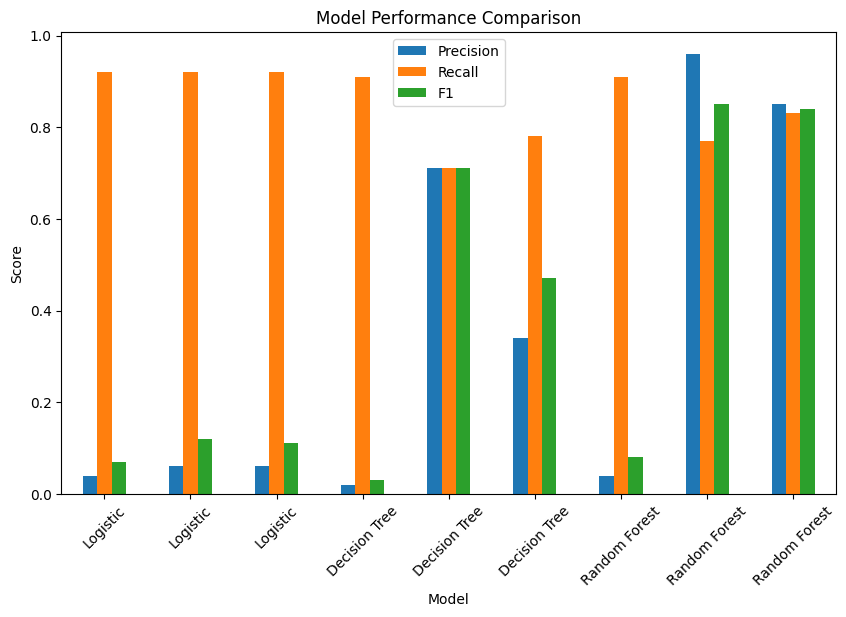

In [66]:
import matplotlib.pyplot as plt

df_results.plot(
    x='Model',
    y=['Precision', 'Recall', 'F1'],
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

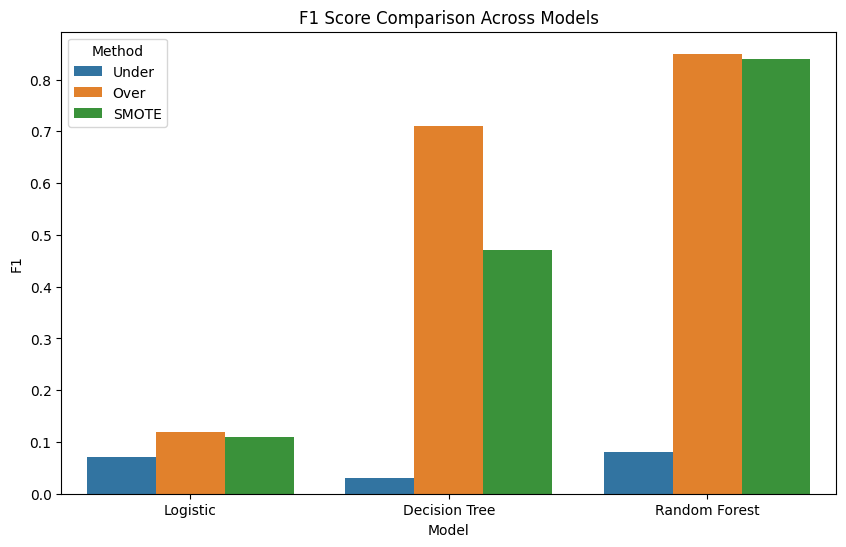

In [67]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=df_results, x='Model', y='F1', hue='Method')
plt.title("F1 Score Comparison Across Models")
plt.show()

In [68]:
best = df_results.sort_values(by='F1', ascending=False).head(1)
print("Best Model:")
print(best)

Best Model:
  Method          Model  Precision  Recall    F1
7   Over  Random Forest       0.96    0.77  0.85


In [69]:
import joblib
joblib.dump(rf_model_sm, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [71]:
import os
print(os.listdir())

['.config', 'model.pkl', 'scaler.pkl', 'creditcard.csv', 'sample_data']
